# Insight agent

After SQL returns rows, TalkDB's insight pipeline runs. Stats are pure pandas (trends, anomalies via Median Absolute Deviation, concentrations). A chart is auto-picked from data shape. A short LLM narrator writes 2–4 sentences **using only the analyzer's computed facts** — so the numbers in the narrative are always correct.

In [1]:
import os
from pathlib import Path

# Locate project root (so relative paths data/, packages/, .env resolve regardless of
# where the notebook was launched from).
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'pyproject.toml').exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError('could not locate project root (no pyproject.toml found upward)')
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

from dotenv import load_dotenv
load_dotenv()
if not (os.environ.get('OPENAI_API_KEY') or os.environ.get('ANTHROPIC_API_KEY')):
    raise RuntimeError('Set OPENAI_API_KEY or ANTHROPIC_API_KEY in your .env before running this notebook.')
print('project root:', PROJECT_ROOT)

project root: /Users/nitingupta/Desktop/talkdb


In [2]:
from talkdb.config.settings import get_settings
from talkdb.core.engine import Engine

engine = Engine(get_settings())
engine.build_index()
print('engine ready')

engine ready


## Ask a time-series question with insights on

In [3]:
result = await engine.ask(
    'What is total revenue by month?',
    with_insights=True,
)
print('SQL:')
print(result.sql)
print(f'\n{result.row_count} rows, confidence {result.confidence}')

SQL:
SELECT strftime('%Y-%m', o.created_at) AS month, SUM(o.total_amount) AS revenue FROM orders o WHERE o.status = 'completed' GROUP BY month ORDER BY month

13 rows, confidence 74


## Narrative

In [4]:
print(result.insight or '(no narrative produced)')

Total revenue increased by 134.5% over the 13-month period, rising from 15.01k to 35.20k. The revenue started at 15,008.89 and reached a maximum of 77,746.38 during this time. There were no anomalies detected in the revenue data. A follow-up question could be: What were the monthly revenue figures for each month?


## Key findings detected by the pandas analyzer

In [5]:
if result.key_findings:
    for f in result.key_findings:
        print(f' • {f}')
else:
    print('(none)')

 • revenue trended up +134.5% over 13 periods (from 15.01k to 35.20k).


## Auto-generated chart

chart type: line
title:      revenue over time


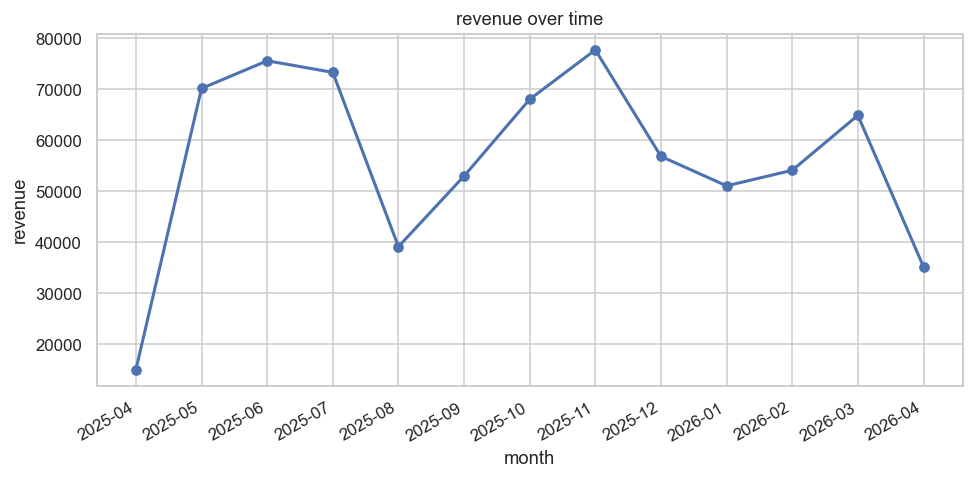

In [6]:
import base64
from IPython.display import Image, display

if result.chart and result.chart.get('image_base64'):
    print(f"chart type: {result.chart.get('type')}")
    print(f"title:      {result.chart.get('title')}")
    display(Image(data=base64.b64decode(result.chart['image_base64'])))
else:
    print(f"(no chart — reason: {result.chart_skipped_reason or 'unknown'})")